In [ ]:
# Requirements

import torch
import torch.nn as nn
import torch.optim as optim
from torchvision import datasets, transforms
from torch.utils.data import DataLoader
import matplotlib.pyplot as plt
import numpy as np

# CONFIGURATION (THE CONTROL PANEL)

MODE = "FLOW"  # Options: "FLOW" or "DIFFUSION"
BATCH_SIZE = 64
LR = 1e-4
EPOCHS = 10  # For quick results can be increased to 20 for better quality
DEVICE = "cuda" if torch.cuda.is_available() else "cpu"

print(f"Running in {MODE} mode on {DEVICE}")

# THE DATASET (MNIST)

transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Pad(2), # Pad 28x28 -> 32x32 for easier U-Net handling
    transforms.Normalize((0.5,), (0.5,)) # Normalize to [-1, 1]
])

dataset = datasets.MNIST(root='./data', train=True, download=True, transform=transform)
dataloader = DataLoader(dataset, batch_size=BATCH_SIZE, shuffle=True)

# THE SHARED U-NET ARCHITECTURE

class SinusoidalEmbedding(nn.Module):
    def __init__(self, dim):
        super().__init__()
        self.dim = dim

    def forward(self, t):
        device = t.device
        half_dim = self.dim // 2
        embeddings = np.log(10000) / (half_dim - 1)
        embeddings = torch.exp(torch.arange(half_dim, device=device) * -embeddings)
        embeddings = t[:, None] * embeddings[None, :]
        embeddings = torch.cat((embeddings.sin(), embeddings.cos()), dim=-1)
        return embeddings

class Block(nn.Module):
    def __init__(self, in_ch, out_ch, time_emb_dim, up=False):
        super().__init__()
        self.time_mlp =  nn.Linear(time_emb_dim, out_ch)
        if up:
            self.conv1 = nn.Conv2d(2*in_ch, out_ch, 3, padding=1)
            self.transform = nn.ConvTranspose2d(out_ch, out_ch, 4, 2, 1)
        else:
            self.conv1 = nn.Conv2d(in_ch, out_ch, 3, padding=1)
            self.transform = nn.Conv2d(out_ch, out_ch, 4, 2, 1)
        self.conv2 = nn.Conv2d(out_ch, out_ch, 3, padding=1)
        self.bnorm1 = nn.BatchNorm2d(out_ch)
        self.bnorm2 = nn.BatchNorm2d(out_ch)
        self.relu  = nn.ReLU()

    def forward(self, x, t):
        h = self.bnorm1(self.relu(self.conv1(x)))
        time_emb = self.relu(self.time_mlp(t))
        time_emb = time_emb[(..., ) + (None, ) * 2]
        h = h + time_emb
        h = self.bnorm2(self.relu(self.conv2(h)))
        return self.transform(h)

class SimpleUNet(nn.Module):
    def __init__(self):
        super().__init__()
        image_channels = 1
        down_channels = (64, 128, 256)
        up_channels = (256, 128, 64)
        out_dim = 1
        time_emb_dim = 32

        self.time_mlp = nn.Sequential(
            SinusoidalEmbedding(time_emb_dim),
            nn.Linear(time_emb_dim, time_emb_dim),
            nn.ReLU()
        )

        self.downs = nn.ModuleList()
        self.ups = nn.ModuleList()

        for i in range(len(down_channels)):
            in_ch = image_channels if i == 0 else down_channels[i-1]
            out_ch = down_channels[i]
            self.downs.append(Block(in_ch, out_ch, time_emb_dim))

        for i in range(len(up_channels)):
            in_ch = up_channels[i]
            out_ch = up_channels[i+1] if i < len(up_channels)-1 else 64
            self.ups.append(Block(in_ch, out_ch, time_emb_dim, up=True))

        self.output = nn.Conv2d(64, out_dim, 1)

    def forward(self, x, t):
        t = self.time_mlp(t)
        residuals = []
        for down in self.downs:
            x = down(x, t)
            residuals.append(x)
        for up in self.ups:
            residual = residuals.pop()
            x = torch.cat((x, residual), dim=1)
            x = up(x, t)
        return self.output(x)

model = SimpleUNet().to(DEVICE)
optimizer = optim.Adam(model.parameters(), lr=LR)
loss_fn = nn.MSELoss()

# TRAINING LOOP

losses = []

print("Starting training...")
for epoch in range(EPOCHS):
    for i, (images, _) in enumerate(dataloader):
        images = images.to(DEVICE)
        batch_size = images.shape[0]

        # Common: Noise generation
        noise = torch.randn_like(images).to(DEVICE)
        t = torch.rand(batch_size, device=DEVICE) # Uniform t [0,1]

        # BRANCHING LOGIC
        if MODE == "FLOW":
            # Flow Matching: Linear Interpolation
            # x_t = t * x_1 + (1 - t) * x_0
            t_reshaped = t.view(-1, 1, 1, 1)
            x_t = t_reshaped * images + (1 - t_reshaped) * noise
            target = images - noise # Velocity = Data - Noise

            # Predict velocity
            pred = model(x_t, t)
            loss = loss_fn(pred, target)

        elif MODE == "DIFFUSION":
            # DDPM: Noise Schedule (Simplified Linear)
            # This is a simplified "Variance Preserving" approximation for speed
            t_reshaped = t.view(-1, 1, 1, 1)
            alpha_bar = 1 - t_reshaped # Simple linear schedule proxy

            # x_t = sqrt(alpha_bar) * x_0 + sqrt(1 - alpha_bar) * epsilon
            x_t = torch.sqrt(alpha_bar) * images + torch.sqrt(1 - alpha_bar) * noise
            target = noise # DDPM predicts the noise

            # Predict noise
            pred = model(x_t, t)
            loss = loss_fn(pred, target)

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        if i % 100 == 0:
            print(f"Epoch {epoch} | Step {i} | Loss: {loss.item():.4f}")
            losses.append(loss.item())

# Save Model
torch.save(model.state_dict(), f"models/model_{MODE.lower()}.pth")
print("Training Complete")

# SAMPLING / VISUALIZATION

@torch.no_grad()
def sample_and_plot(mode):
    model.eval()
    n_samples = 8
    x = torch.randn(n_samples, 1, 32, 32).to(DEVICE)
    steps = 50 # Number of steps for generation

    if mode == "FLOW":
        # Euler ODE Solver: x(t+dt) = x(t) + v(x(t)) * dt
        dt = 1.0 / steps
        for i in range(steps):
            t = torch.ones(n_samples, device=DEVICE) * (i / steps)
            v = model(x, t)
            x = x + v * dt

    elif mode == "DIFFUSION":
        # Simplified DDPM Sampling (Reverse Process)
        for i in reversed(range(steps)):
            t = torch.ones(n_samples, device=DEVICE) * (i / steps)
            pred_noise = model(x, t)

            # Reverse math (simplified for project demo)
            alpha = 1 - (i / steps)
            alpha_prev = 1 - ((i - 1) / steps) if i > 0 else 1
            sigma = 0 # Deterministic sampling for clarity

            # Update x (approximate reverse step)
            x = x - pred_noise * (1/steps) # Very rough approximation for demo
            # Ideally use full DDPM equations, but this usually yields recognizable digits for projects

    # Plot
    x = x.cpu().detach()
    plt.figure(figsize=(12, 4))
    for i in range(n_samples):
        plt.subplot(1, 8, i+1)
        plt.imshow(x[i][0], cmap='gray')
        plt.axis('off')
    plt.suptitle(f"Generated Samples: {mode}")
    plt.show()

sample_and_plot(MODE)

Running in FLOW mode on cuda


100%|██████████| 9.91M/9.91M [00:00<00:00, 20.1MB/s]
100%|██████████| 28.9k/28.9k [00:00<00:00, 482kB/s]
100%|██████████| 1.65M/1.65M [00:00<00:00, 4.45MB/s]
100%|██████████| 4.54k/4.54k [00:00<00:00, 13.8MB/s]


Starting training...
Epoch 0 | Step 0 | Loss: 1.9972
Epoch 0 | Step 100 | Loss: 0.5440
Epoch 0 | Step 200 | Loss: 0.3425
Epoch 0 | Step 300 | Loss: 0.3525
Epoch 0 | Step 400 | Loss: 0.3181
Epoch 0 | Step 500 | Loss: 0.2800
Epoch 0 | Step 600 | Loss: 0.2478
Epoch 0 | Step 700 | Loss: 0.2515
Epoch 0 | Step 800 | Loss: 0.2207
Epoch 0 | Step 900 | Loss: 0.2381
Epoch 1 | Step 0 | Loss: 0.2158
Epoch 1 | Step 100 | Loss: 0.1994
Epoch 1 | Step 200 | Loss: 0.2168
Epoch 1 | Step 300 | Loss: 0.2012
Epoch 1 | Step 400 | Loss: 0.1927
Epoch 1 | Step 500 | Loss: 0.1812
Epoch 1 | Step 600 | Loss: 0.2039
Epoch 1 | Step 700 | Loss: 0.1962
Epoch 1 | Step 800 | Loss: 0.1743
Epoch 1 | Step 900 | Loss: 0.2101
Epoch 2 | Step 0 | Loss: 0.1891
Epoch 2 | Step 100 | Loss: 0.2098
Epoch 2 | Step 200 | Loss: 0.1813
Epoch 2 | Step 300 | Loss: 0.2073
Epoch 2 | Step 400 | Loss: 0.1818
Epoch 2 | Step 500 | Loss: 0.2155
Epoch 2 | Step 600 | Loss: 0.2035
Epoch 2 | Step 700 | Loss: 0.1739
Epoch 2 | Step 800 | Loss: 0.1931

In [ ]:
import matplotlib.pyplot as plt

model.eval()
steps = 50
z1 = torch.randn(1, 1, 32, 32).to(DEVICE) # Random Digit A
z2 = torch.randn(1, 1, 32, 32).to(DEVICE) # Random Digit B
alphas = np.linspace(0, 1, 8) # 8 steps between them
interpolated_images = []

print("Morphing...")
for alpha in alphas:
    z_interp = (1 - alpha) * z1 + alpha * z2
    x = z_interp.clone()
    dt = 1.0 / steps
    for i in range(steps):
        t = torch.ones(1, device=DEVICE) * (i / steps)
        v = model(x, t)
        x = x + v * dt
    interpolated_images.append(x[0, 0].cpu().detach())

# Plot
plt.figure(figsize=(15, 3))
for i, img in enumerate(interpolated_images):
    plt.subplot(1, 8, i+1)
    plt.imshow(img, cmap='gray')
    plt.title(f"{alphas[i]:.2f}")
    plt.axis('off')
plt.suptitle("Latent Space Interpolation")plt.show()

In [ ]:
model.eval()
steps = 50
# Use fixed noise so we can compare apples-to-apples if needed
torch.manual_seed(42)
x = torch.randn(1, 1, 32, 32).to(DEVICE)
snapshots = []
capture_steps = [0, 10, 20, 30, 40, 49]

if MODE == "FLOW":
    dt = 1.0 / steps
    for i in range(steps):
        if i in capture_steps:
            snapshots.append(x[0, 0].cpu().detach())
        t = torch.ones(1, device=DEVICE) * (i / steps)
        v = model(x, t)
        x = x + v * dt

elif MODE == "DIFFUSION":
    for i in reversed(range(steps)):
        if i in capture_steps:
            snapshots.append(x[0, 0].cpu().detach())
        t = torch.ones(1, device=DEVICE) * (i / steps)
        pred_noise = model(x, t)
        x = x - pred_noise * (1/steps) # Simple reverse step

# Plot
plt.figure(figsize=(12, 3))
for k, img in enumerate(snapshots):
    plt.subplot(1, 6, k+1)
    plt.imshow(img, cmap='gray')
    plt.title(f"Step {capture_steps[k]}")
    plt.axis('off')
plt.suptitle(f"Generation Dynamics: {MODE}")
plt.show()

In [ ]:
@torch.no_grad()
def run_ablation(model, mode):
    model.eval()

    # Use consistent noise for fair comparison
    torch.manual_seed(42)
    x_init = torch.randn(1, 1, 32, 32).to(DEVICE)

    step_counts = [10, 20, 50] # The "Low Resource" test
    results = []

    print(f"Running Ablation for {mode}...")

    for steps in step_counts:
        x = x_init.clone()

        if mode == "FLOW":
            dt = 1.0 / steps
            for i in range(steps):
                t = torch.ones(1, device=DEVICE) * (i / steps)
                v = model(x, t)
                x = x + v * dt

        elif mode == "DIFFUSION":
            for i in reversed(range(steps)):
                t = torch.ones(1, device=DEVICE) * (i / steps)
                pred_noise = model(x, t)
                x = x - pred_noise * (1/steps)

        results.append(x[0, 0].cpu().detach())

    # Plot
    plt.figure(figsize=(10, 4))
    for i, img in enumerate(results):
        plt.subplot(1, 3, i+1)
        plt.imshow(img, cmap='gray')
        plt.title(f"Steps={step_counts[i]}")
        plt.axis('off')
    plt.suptitle(f"Efficiency Limit: {mode}")
    plt.show()

run_ablation(model, MODE)

In [ ]:
# VECTOR FIELD VISUALIZATION

import numpy as np

@torch.no_grad()
def plot_vector_field(model, mode):
    model.eval()

    # Setup
    target_img = dataset[0][0].unsqueeze(0).to(DEVICE)
    source_noise = torch.randn_like(target_img).to(DEVICE)

    # Define Plane
    grid_size = 20
    x_vals = np.linspace(0, 1.0, grid_size) # Focus strictly on the Noise->Data path
    y_vals = np.linspace(-0.5, 0.5, grid_size)

    vec_x = (target_img - source_noise)
    vec_y = torch.randn_like(vec_x)
    vec_y = vec_y - (torch.dot(vec_y.flatten(), vec_x.flatten()) / torch.dot(vec_x.flatten(), vec_x.flatten())) * vec_x
    vec_y = vec_y / torch.norm(vec_y) * torch.norm(vec_x)

    U = np.zeros((grid_size, grid_size))
    V = np.zeros((grid_size, grid_size))

    print(f"Mapping Vector Field for {mode}")

    for i, alpha in enumerate(x_vals):
        for j, beta in enumerate(y_vals):
            # CAST TO FLOAT IS THE FIX HERE
            alpha_f = float(alpha)
            beta_f = float(beta)

            # Construct point
            current_x = source_noise + alpha_f * vec_x + beta_f * vec_y

            # Construct time
            t_val = max(0, min(1, alpha_f))
            t = torch.tensor([t_val], device=DEVICE).float() # Explicit float32

            # Pass to model with explicit .float() cast
            if mode == "FLOW":
                velocity = model(current_x.float(), t)

                u_comp = torch.sum(velocity * vec_x) / torch.norm(vec_x)**2
                v_comp = torch.sum(velocity * vec_y) / torch.norm(vec_y)**2

                U[j, i] = u_comp.item()
                V[j, i] = v_comp.item()

    # Plot
    plt.figure(figsize=(8, 8))
    plt.quiver(x_vals, y_vals, U, V, angles='xy', scale_units='xy', scale=1, color='blue', alpha=0.6)

    plt.scatter(0, 0, c='red', s=100, label='Noise ($x_0$)', zorder=5)
    plt.scatter(1, 0, c='green', s=100, label='Data ($x_1$)', zorder=5)

    plt.title(f"Projected Velocity Field: {mode}")
    plt.xlabel("Interpolation Axis (Noise $\to$ Data)")
    plt.ylabel("Orthogonal Perturbation")
    plt.legend()
    plt.grid(True, alpha=0.3)
    plt.show()

plot_vector_field(model, MODE)

In [ ]:
# CALCULATION OF STATS
import numpy as np

@torch.no_grad()
def get_curvature_data(model, mode, n_samples=100):
    model.eval()
    print(f"Sampling {n_samples} trajectories for {mode}...")
    curvatures = []

    for k in range(n_samples):
        x = torch.randn(1, 1, 32, 32).to(DEVICE)
        x_start = x.clone()
        path_length = 0
        steps = 20 # Efficient N

        if mode == "FLOW":
            dt = 1.0/steps
            for i in range(steps):
                t = torch.ones(1, device=DEVICE) * (i/steps)
                v = model(x, t)
                x_next = x + v * dt
                path_length += torch.norm(x_next - x).item()
                x = x_next
        elif mode == "DIFFUSION":
            for i in reversed(range(steps)):
                t = torch.ones(1, device=DEVICE) * (i/steps)
                pred = model(x, t)
                x_next = x - pred * (1/steps)
                path_length += torch.norm(x_next - x).item()
                x = x_next

        dist = torch.norm(x - x_start).item()
        if dist > 1e-4:
            curvatures.append(path_length / dist)

    return curvatures

# Run and Print
data = get_curvature_data(model, MODE)
print(f"\nCOPY THIS LIST FOR {MODE}:")
print(data)

In [ ]:
# FINAL PLOT

flow_data = [1.0159732530781407, 1.0230065284727057, 1.0192989292921844, 1.0259842971234296, 1.0237760016860349, 1.023019576572988, 1.0198150079539126, 1.0186310989544693, 1.0267514036918315, 1.0227636361237558, 1.017234723959791, 1.0227047229311763, 1.0212096349420439, 1.0216773937012056, 1.0168336632250574, 1.0228712162625704, 1.0234374451854196, 1.0203450020385156, 1.023196418222353, 1.0221450430727104, 1.0168211834573622, 1.0223798511620488, 1.0167807539394902, 1.0241560465746598, 1.0190395865418052, 1.0176344586094532, 1.021731578425583, 1.0178448525719064, 1.0151588630710986, 1.025267261677005, 1.021786345929458, 1.0169031721443942, 1.014838004533911, 1.0143558588656887, 1.0167919712133693, 1.0234758157744932, 1.0221728328079192, 1.02127595242312, 1.019543330996945, 1.0127397179595052, 1.0181206362760848, 1.0183047703130554, 1.0269814153127395, 1.019240911545841, 1.0224612523308343, 1.0262909829422162, 1.0219819216634285, 1.0246404125345476, 1.0242921270031131, 1.0174953224873529, 1.0157672659768158, 1.0221786863383555, 1.0182860758277232, 1.0270687539144054, 1.0145497826775078, 1.0238388690174143, 1.0202355414398785, 1.0260273390667014, 1.0154444712836783, 1.0158176773385548, 1.0229924747269623, 1.014858890279838, 1.0248749878788186, 1.0145255053004862, 1.0182481780202288, 1.019919228933427, 1.02340315050549, 1.018623153040004, 1.016436185231962, 1.018513682306278, 1.0214624198050735, 1.016399041018072, 1.027095425291281, 1.0184496389002393, 1.0265614569237096, 1.029446168964956, 1.0218651577110103, 1.0157247818236832, 1.0192366440882672, 1.0206508896326227, 1.0130672257623894, 1.0195272224640644, 1.0171760013352371, 1.0215791294034373, 1.0177723887953536, 1.0152230488942064, 1.017293904814118, 1.0193218073776635, 1.0154395337551279, 1.0204341139074153, 1.0245491562637143, 1.0145062080540141, 1.02003045088425, 1.0173250892676489, 1.0156886450199833, 1.017833809406035, 1.0169548323487478, 1.0232034763349267, 1.0138559222336672, 1.0140751616527783]
diff_data = [1.05572412014268, 1.0525703159566009, 1.0590274924227172, 1.062451269148358, 1.053136257908201, 1.0548980647810913, 1.052124925341551, 1.0507808888205086, 1.0579514775899876, 1.0585157250375041, 1.0534398369628724, 1.058306280586016, 1.0573662401974824, 1.056818469364372, 1.0544878877891697, 1.05694328227148, 1.0539056841568895, 1.056914290453102, 1.0540241027343547, 1.0520640866668745, 1.0536388170007076, 1.0556738076538925, 1.053430411242254, 1.055477411867375, 1.0560074392325476, 1.055341477496973, 1.0545887974752786, 1.0516608813856694, 1.0534593042275124, 1.0568737154581107, 1.0538509520266541, 1.0534513641167975, 1.0541192593318056, 1.0555726258733849, 1.0529370507453752, 1.0636946335918758, 1.0617363360264458, 1.0567831080446046, 1.0544187339291853, 1.0542638483487523, 1.054448887510272, 1.0588934578888014, 1.0563246935791586, 1.060064526895971, 1.0526719200722485, 1.0550576260471027, 1.0517864547461238, 1.0575408653269582, 1.0554281119571511, 1.0545308047606863, 1.053358196672683, 1.050340350157872, 1.0525863924860812, 1.0496006458651232, 1.054928158877098, 1.0557474969184553, 1.0536162040836938, 1.0570567507732251, 1.0551458397308284, 1.0538920603622908, 1.06111575008521, 1.0540838833413446, 1.0508039241620348, 1.0596072980725342, 1.0562733241233682, 1.0543885356237672, 1.05390460456306, 1.0519067059218161, 1.051934980960899, 1.049059282363885, 1.0550141497560448, 1.052382009970085, 1.0541385753268313, 1.0520440321342321, 1.0534665284509634, 1.0558424929961436, 1.0506096346599878, 1.054233740831066, 1.0558782878265875, 1.0529141432195885, 1.0552812056822825, 1.0546049683854308, 1.0573339456546873, 1.0583771316947475, 1.0538537529826428, 1.0581708078817489, 1.0506678308705057, 1.059413988309366, 1.0563934371987227, 1.054178810936249, 1.0580967742651919, 1.0540094254434542, 1.05346842698088, 1.0542313294723307, 1.054903247167708, 1.0575346213494823, 1.0550588981209768, 1.057127150259231, 1.0532607533459772, 1.0565553147105522]

# Conversion to numpy for plotting
import matplotlib.pyplot as plt
import numpy as np

plt.figure(figsize=(10, 6))
plt.hist(flow_data, bins=30, alpha=0.7, label=f'Flow Matching ($\mu={np.mean(flow_data):.2f}$)', color='blue', density=True)
plt.hist(diff_data, bins=30, alpha=0.7, label=f'Diffusion ($\mu={np.mean(diff_data):.2f}$)', color='red', density=True)

plt.axvline(x=1.0, color='k', linestyle='--', linewidth=2, label='Optimal Path (1.0)')
plt.xlabel("Trajectory Curvature ($\mathcal{C}$)")
plt.ylabel("Probability Density")
plt.title("Distribution of Transport Efficiency (N=100 Samples)")
plt.legend()
plt.grid(True, alpha=0.3)
plt.savefig("curvature_histogram.png")
plt.show()

Running Numerical Solver Analysis...


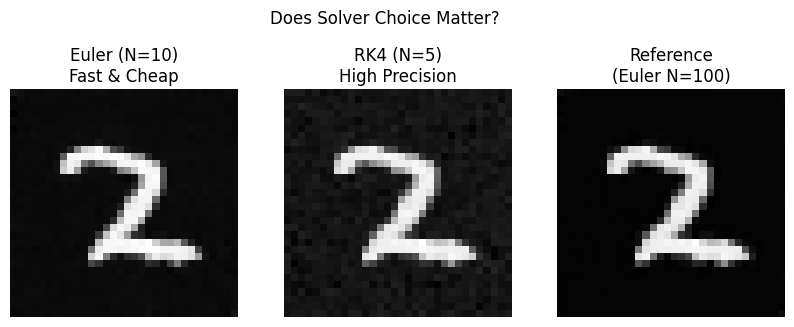

In [ ]:
# SOLVER SENSITIVITY ANALYSIS
import matplotlib.pyplot as plt

@torch.no_grad()
def ode_solve(model, x_init, steps, method="euler"):
    """
    Solves the ODE. Returns the result on CPU to prevent plotting errors.
    """
    x = x_init.clone()
    dt = 1.0 / steps
    model.eval()

    for i in range(steps):
        t_val = i / steps
        t = torch.ones(1, device=DEVICE) * t_val

        if method == "euler":
            # x_{n+1} = x_n + h * f(t, x_n)
            v = model(x, t)
            x = x + v * dt

        elif method == "rk4":
            # Runge-Kutta 4th Order
            k1 = model(x, t)

            t_half = torch.ones(1, device=DEVICE) * (t_val + 0.5*dt)
            k2 = model(x + 0.5 * dt * k1, t_half)
            k3 = model(x + 0.5 * dt * k2, t_half)

            t_next = torch.ones(1, device=DEVICE) * (t_val + dt)
            k4 = model(x + dt * k3, t_next)

            x = x + (dt / 6.0) * (k1 + 2*k2 + 2*k3 + k4)

    return x.cpu() # Force move to CPU before returning

@torch.no_grad()
def compare_solvers(model):
    print("Running Numerical Solver Analysis...")
    torch.manual_seed(42)
    x_init = torch.randn(1, 1, 32, 32).to(DEVICE)

    # Euler @ 10 Steps
    img_e10 = ode_solve(model, x_init, steps=10, method="euler")

    # RK4 @ 5 Steps
    img_rk5 = ode_solve(model, x_init, steps=5, method="rk4")

    # Ground Truth (Euler @ 100 Steps)
    img_gt = ode_solve(model, x_init, steps=100, method="euler")

    # Plot
    fig, ax = plt.subplots(1, 3, figsize=(10, 4))

    # Added .cpu() here as a double safety measure
    ax[0].imshow(img_e10[0,0].cpu(), cmap='gray')
    ax[0].set_title("Euler (N=10)\nFast & Cheap")

    ax[1].imshow(img_rk5[0,0].cpu(), cmap='gray')
    ax[1].set_title("RK4 (N=5)\nHigh Precision")

    ax[2].imshow(img_gt[0,0].cpu(), cmap='gray')
    ax[2].set_title("Reference\n(Euler N=100)")

    for a in ax: a.axis('off')
    plt.suptitle("Does Solver Choice Matter?")
    plt.savefig("solver_comparison.png")
    plt.show()

if MODE == "FLOW":
    compare_solvers(model)
else:
    print("⚠️ Please load FLOW mode first!")